In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

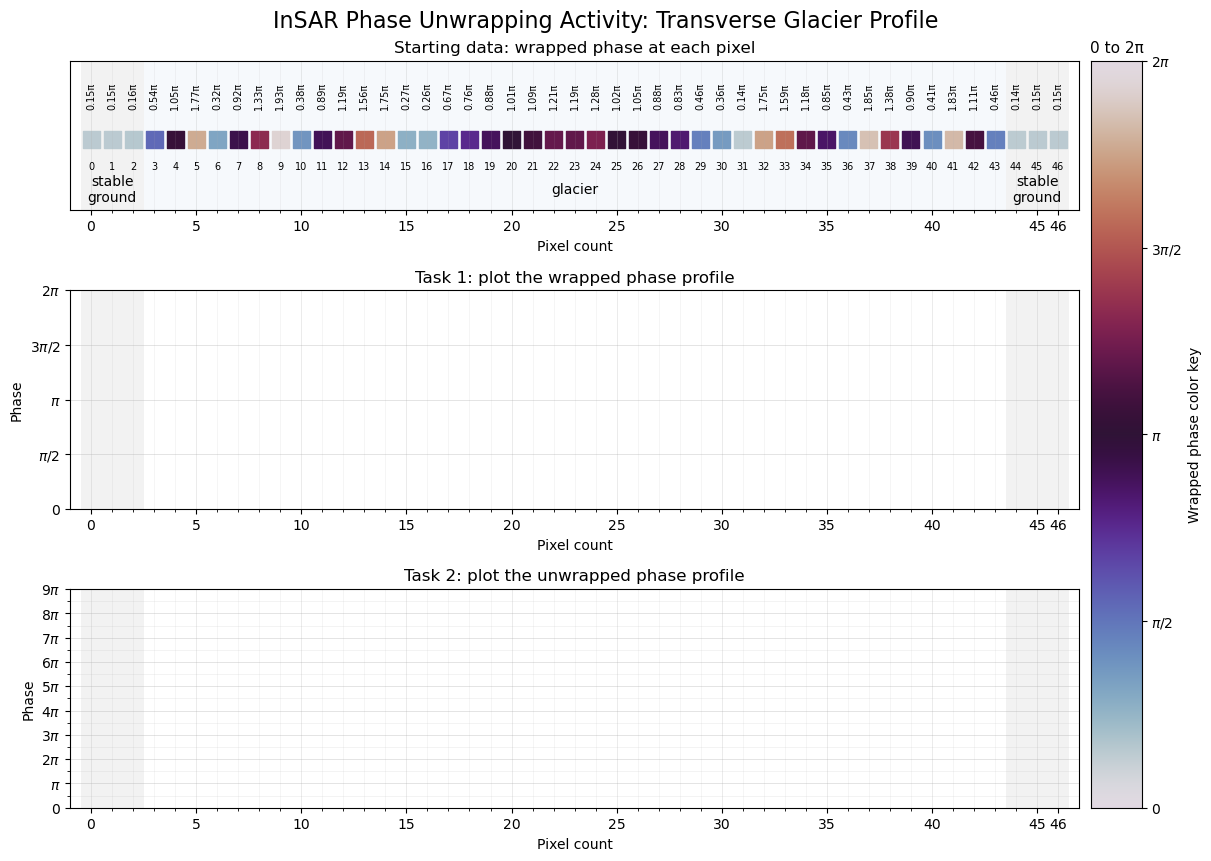

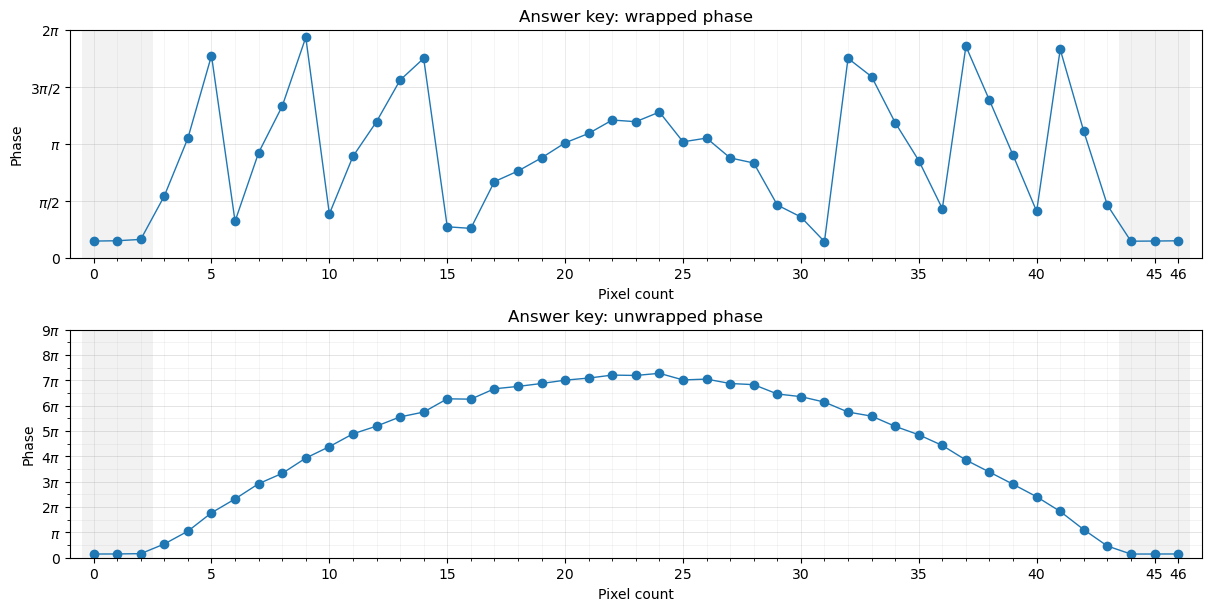

Saved worksheet to: insar_phase_unwrapping_activity_transverse_stable.png
Saved answer key to: insar_phase_unwrapping_answer_key_transverse_stable.png
Saved CSV to: wrapped_phase_values_transverse_stable.csv


In [18]:
# ============================================================
# User-adjustable settings
# ============================================================

# Pixel counts
n_glacier_pixels = 41
n_stable_each_side = 3
n_pixels = n_glacier_pixels + 2 * n_stable_each_side

# Noise
noise_std_glacier = 0.2       # radians
noise_std_stable = 0.02        # radians
seed = 4

# Glacier transverse profile
edge_phase = 0.5 * np.pi       # near glacier margins
center_phase = 7.2 * np.pi     # peak at glacier center
center_offset_pixels = 0       # shift peak left/right
power = 2.0                    # 2 = parabola-like

# Stable ground phase
stable_phase = 0.15 * np.pi    # could also set to 0 if you want

# Label format above pixels: "pi" or "rad"
value_label_mode = "pi"

# Output files
out_dir = Path(".")
worksheet_path = out_dir / "insar_phase_unwrapping_activity_transverse_stable.png"
answer_key_path = out_dir / "insar_phase_unwrapping_answer_key_transverse_stable.png"
csv_path = out_dir / "wrapped_phase_values_transverse_stable.csv"


# ============================================================
# Helpers
# ============================================================

def pi_label(k):
    if k == 0:
        return "0"
    elif k == 1:
        return r"$\pi$"
    else:
        return rf"${k}\pi$"


def add_pixel_guides(ax, n_pixels, major_step=5):
    """
    Add subtle vertical guide lines centered on each pixel position.
    These align with integer x values, i.e., the dot centers in the answer key.
    """
    # Major ticks for readable labels
    major_ticks = np.arange(0, n_pixels, major_step)
    if major_ticks[-1] != n_pixels - 1:
        major_ticks = np.append(major_ticks, n_pixels - 1)

    # Minor ticks at every pixel center
    minor_ticks = np.arange(0, n_pixels, 1)

    ax.set_xticks(major_ticks)
    ax.set_xticks(minor_ticks, minor=True)

    # Light vertical guides at every pixel
    ax.grid(True, axis="x", which="minor", linewidth=0.5, alpha=0.18)

    # Optionally keep the major x-grid a little darker
    ax.grid(True, axis="x", which="major", linewidth=0.7, alpha=0.25)


def set_phase_axis(ax, ymax_pi, label_half_pi=False):
    """
    Major ticks at pi, minor ticks at pi/2.
    """
    major = np.arange(0, ymax_pi + 1, 1) * np.pi
    minor = np.arange(0, 2 * ymax_pi + 1, 1) * np.pi / 2

    ax.set_ylim(0, ymax_pi * np.pi)
    ax.set_yticks(major)
    ax.set_yticklabels([pi_label(k) for k in range(ymax_pi + 1)])
    ax.set_yticks(minor, minor=True)

    if label_half_pi and ymax_pi <= 2:
        ticks = np.array([0, 0.5, 1, 1.5, 2]) * np.pi
        labels = ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
        ax.set_yticks(ticks)
        ax.set_yticklabels(labels)

    ax.set_xlabel("Pixel count")
    ax.set_ylabel("Phase")

    # Horizontal phase guides
    ax.grid(True, axis="y", which="major", linewidth=0.7, alpha=0.35)
    ax.grid(True, axis="y", which="minor", linewidth=0.4, alpha=0.25)


def transverse_glacier_phase(n_glacier_pixels, edge_phase, center_phase,
                             center_offset_pixels=0, power=2.0):
    """
    Low at glacier edges, high in center.
    """
    xg = np.arange(n_glacier_pixels)
    center = (n_glacier_pixels - 1) / 2 + center_offset_pixels
    half_width = (n_glacier_pixels - 1) / 2

    r = np.abs((xg - center) / half_width)
    r = np.clip(r, 0, 1)

    shape = 1 - r**power
    phase = edge_phase + (center_phase - edge_phase) * shape
    return phase


def format_phase_value(val, mode="pi"):
    """
    Format wrapped phase values to print above each pixel.
    """
    if mode == "pi":
        return f"{val/np.pi:.2f}π"
    elif mode == "rad":
        return f"{val:.2f}"
    else:
        raise ValueError("mode must be 'pi' or 'rad'")


# ============================================================
# Create synthetic profile
# ============================================================

rng = np.random.default_rng(seed)

# Glacier-only unwrapped phase
glacier_phase = transverse_glacier_phase(
    n_glacier_pixels=n_glacier_pixels,
    edge_phase=edge_phase,
    center_phase=center_phase,
    center_offset_pixels=center_offset_pixels,
    power=power
)

# Add stable ground on both sides
left_stable = np.full(n_stable_each_side, stable_phase)
right_stable = np.full(n_stable_each_side, stable_phase)

true_phase = np.concatenate([left_stable, glacier_phase, right_stable])

# Add noise
noise = np.concatenate([
    rng.normal(0, noise_std_stable, n_stable_each_side),
    rng.normal(0, noise_std_glacier, n_glacier_pixels),
    rng.normal(0, noise_std_stable, n_stable_each_side),
])

true_phase_noisy = true_phase + noise

# Wrapped phase in [0, 2pi)
wrapped_phase = np.mod(true_phase_noisy, 2 * np.pi)

# Pixel coordinates
x = np.arange(n_pixels)

# Regions
glacier_start = n_stable_each_side
glacier_end = n_stable_each_side + n_glacier_pixels - 1

# Save CSV
df = pd.DataFrame({
    "pixel": x,
    "region": ["stable"] * n_stable_each_side
              + ["glacier"] * n_glacier_pixels
              + ["stable"] * n_stable_each_side,
    "wrapped_phase_rad": wrapped_phase,
    "wrapped_phase_pi_units": wrapped_phase / np.pi,
    "unwrapped_phase_rad_answer": true_phase_noisy,
    "unwrapped_phase_pi_units_answer": true_phase_noisy / np.pi
})
df.to_csv(csv_path, index=False)

# Dynamic y max for unwrapped phase
ymax_unwrapped_pi = int(np.ceil(true_phase_noisy.max() / np.pi)) + 1


# ============================================================
# Student worksheet
# ============================================================

fig = plt.figure(figsize=(12, 8.5), constrained_layout=True)
gs = fig.add_gridspec(
    nrows=3, ncols=2,
    width_ratios=[20, 1],
    height_ratios=[1.5, 2.2, 2.2]
)

# ------------------------------------------------------------
# Starting data strip
# ------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])

# Shade stable ground and glacier zones
ax1.axvspan(-0.5, n_stable_each_side - 0.5, alpha=0.10, facecolor='gray')
ax1.axvspan(glacier_start - 0.5, glacier_end + 0.5, alpha=0.04)
ax1.axvspan(glacier_end + 0.5, n_pixels - 0.5, alpha=0.10, facecolor='gray')

# Colored pixel strip
ax1.scatter(
    x,
    np.zeros_like(x),
    c=wrapped_phase,
    cmap="twilight",
    vmin=0,
    vmax=2 * np.pi,
    s=150,
    marker="s"
)

# Wrapped phase value above each pixel
for xi, val in zip(x, wrapped_phase):
    ax1.text(
        xi, 0.16,
        format_phase_value(val, mode=value_label_mode),
        ha="center", va="bottom",
        rotation=90, fontsize=7
    )

# Labels for regions
ax1.text((n_stable_each_side - 1) / 2, -0.27, "stable\nground",
         ha="center", va="center", fontsize=10)
ax1.text((glacier_start + glacier_end) / 2, -0.27, "glacier",
         ha="center", va="center", fontsize=10)
ax1.text((glacier_end + 1 + n_pixels - 1) / 2, -0.27, "stable\nground",
         ha="center", va="center", fontsize=10)

# Pixel numbers below each colored pixel
for xi in x:
    ax1.text(
        xi, -0.12,
        str(xi),
        ha="center", va="top",
        fontsize=7
    )

ax1.set_xlim(-1, n_pixels)
ax1.set_ylim(-0.38, 0.42)   # enough room for labels above and below
ax1.set_yticks([])
ax1.set_xticks([])          # hide default x ticks; we are drawing our own
ax1.set_xlabel("Pixel count")
ax1.set_title("Starting data: wrapped phase at each pixel")
add_pixel_guides(ax1, n_pixels)

# ------------------------------------------------------------
# Wrapped phase plotting axes
# ------------------------------------------------------------
ax2 = fig.add_subplot(gs[1, 0])
set_phase_axis(ax2, ymax_pi=2, label_half_pi=True)
ax2.set_xlim(-1, n_pixels)
ax2.axvspan(-0.5, n_stable_each_side - 0.5, alpha=0.10, facecolor='gray')
ax2.axvspan(glacier_end + 0.5, n_pixels - 0.5, alpha=0.10, facecolor='gray')
add_pixel_guides(ax2, n_pixels)
ax2.set_title("Task 1: plot the wrapped phase profile")

# ------------------------------------------------------------
# Unwrapped phase plotting axes
# ------------------------------------------------------------
ax3 = fig.add_subplot(gs[2, 0])
set_phase_axis(ax3, ymax_pi=ymax_unwrapped_pi, label_half_pi=False)
ax3.set_xlim(-1, n_pixels)
ax3.axvspan(-0.5, n_stable_each_side - 0.5, alpha=0.10, facecolor='gray')
ax3.axvspan(glacier_end + 0.5, n_pixels - 0.5, alpha=0.10, facecolor='gray')
add_pixel_guides(ax3, n_pixels)
ax3.set_title("Task 2: plot the unwrapped phase profile")

# ------------------------------------------------------------
# Vertical colorbar on right
# ------------------------------------------------------------
ax_cb = fig.add_subplot(gs[:, 1])

phase_strip = np.linspace(0, 2 * np.pi, 512)[:, None]
ax_cb.imshow(
    phase_strip,
    aspect="auto",
    extent=[0, 1, 0, 2 * np.pi],
    cmap="twilight",
    origin="lower"
)
ax_cb.set_xticks([])
ax_cb.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax_cb.set_yticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax_cb.yaxis.tick_right()
ax_cb.yaxis.set_label_position("right")
ax_cb.set_ylabel("Wrapped phase color key")
ax_cb.set_title("0 to 2π", fontsize=11)

fig.suptitle("InSAR Phase Unwrapping Activity: Transverse Glacier Profile", fontsize=16)
fig.savefig(worksheet_path, dpi=200, bbox_inches="tight")
plt.show()


# ============================================================
# Answer key
# ============================================================

fig2 = plt.figure(figsize=(12, 6), constrained_layout=True)
gs2 = fig2.add_gridspec(nrows=2, ncols=1)

# Wrapped answer
ax4 = fig2.add_subplot(gs2[0])
ax4.plot(x, wrapped_phase, marker="o", linewidth=1)
set_phase_axis(ax4, ymax_pi=2, label_half_pi=True)
ax4.set_xlim(-1, n_pixels)
ax4.axvspan(-0.5, n_stable_each_side - 0.5, alpha=0.10, facecolor='gray')
ax4.axvspan(glacier_end + 0.5, n_pixels - 0.5, alpha=0.10, facecolor='gray')
add_pixel_guides(ax4, n_pixels)
ax4.set_title("Answer key: wrapped phase")

# Unwrapped answer
ax5 = fig2.add_subplot(gs2[1])
ax5.plot(x, true_phase_noisy, marker="o", linewidth=1)
set_phase_axis(ax5, ymax_pi=ymax_unwrapped_pi, label_half_pi=False)
ax5.set_xlim(-1, n_pixels)
ax5.axvspan(-0.5, n_stable_each_side - 0.5, alpha=0.10, facecolor='gray')
ax5.axvspan(glacier_end + 0.5, n_pixels - 0.5, alpha=0.10, facecolor='gray')
add_pixel_guides(ax5, n_pixels)
ax5.set_title("Answer key: unwrapped phase")

fig2.savefig(answer_key_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved worksheet to: {worksheet_path}")
print(f"Saved answer key to: {answer_key_path}")
print(f"Saved CSV to: {csv_path}")

Max adjacent observed phase step: 2.81π
Max adjacent residual phase step: 0.58π


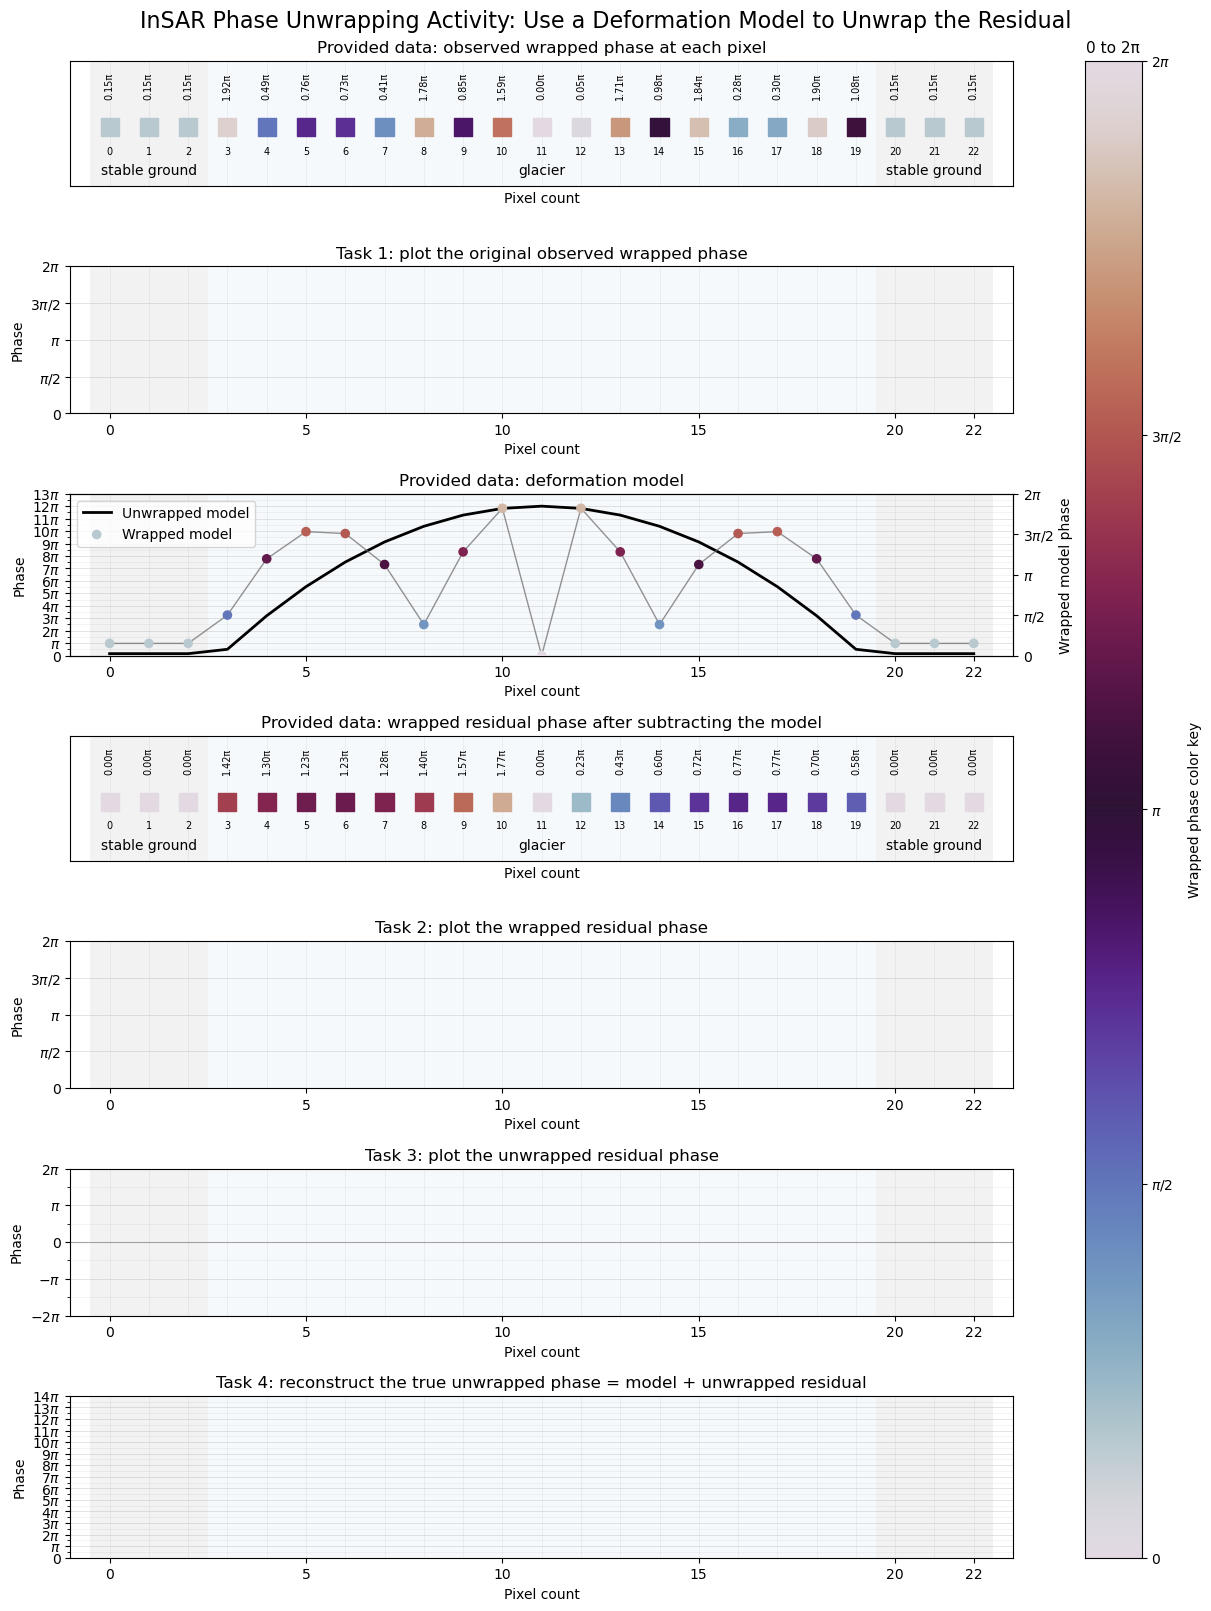

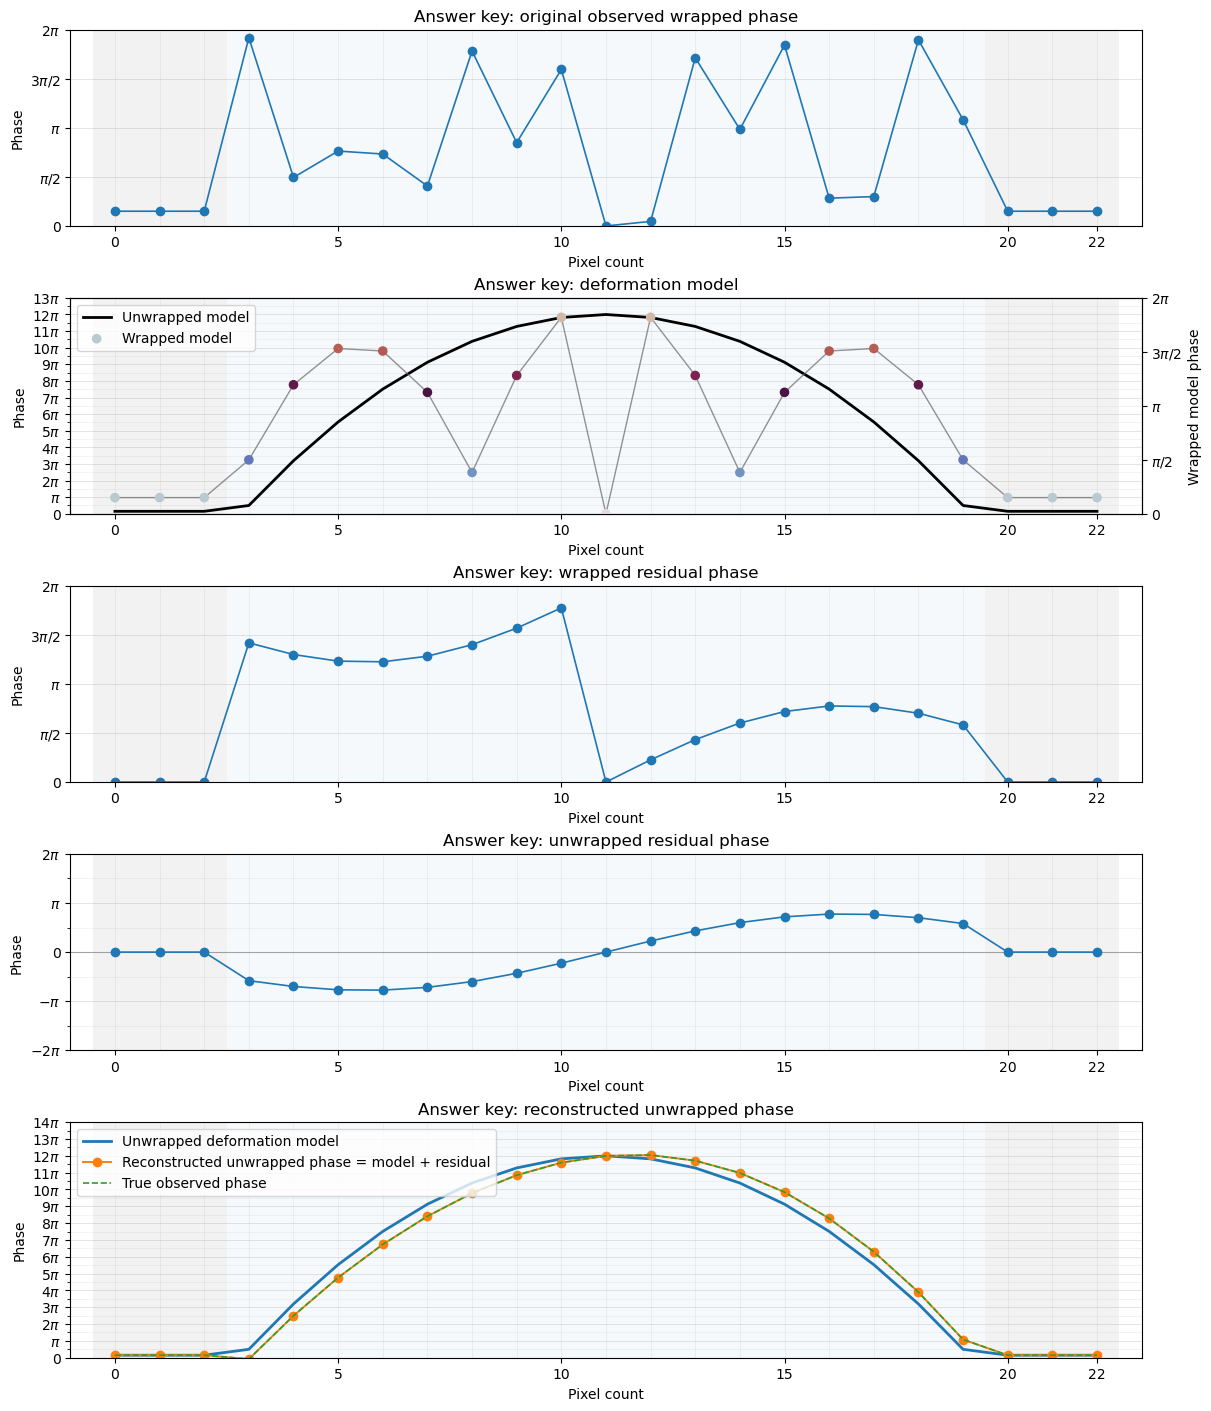

Saved worksheet to:  insar_unwrapping_with_model_activity.png
Saved answer key to: insar_unwrapping_with_model_answer_key.png
Saved CSV to:        insar_unwrapping_with_model_values.csv


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ============================================================
# User-adjustable settings
# ============================================================

# Geometry
n_glacier_pixels = 17
n_stable_each_side = 3
n_pixels = n_glacier_pixels + 2 * n_stable_each_side

# Stable ground
stable_phase = 0.15 * np.pi

# Glacier model phase: intentionally steep
model_edge_phase = 0.5 * np.pi
model_center_phase = 12.0 * np.pi
model_power = 2.0
model_center_offset_pixels = 0

# Residual phase: small enough to unwrap after model subtraction
residual_amp1 = 0.65 * np.pi
residual_amp2 = 0.20 * np.pi

# Label format in top strips: "pi" or "rad"
value_label_mode = "pi"

# Output paths
out_dir = Path(".")
worksheet_path = out_dir / "insar_unwrapping_with_model_activity.png"
answer_key_path = out_dir / "insar_unwrapping_with_model_answer_key.png"
csv_path = out_dir / "insar_unwrapping_with_model_values.csv"


# ============================================================
# Helpers
# ============================================================

def integer_pi_label(k):
    if k == 0:
        return "0"
    elif k == 1:
        return r"$\pi$"
    elif k == -1:
        return r"$-\pi$"
    else:
        return rf"${k}\pi$"


def format_phase_value(val, mode="pi"):
    if mode == "pi":
        return f"{val/np.pi:.2f}π"
    elif mode == "rad":
        return f"{val:.2f}"
    else:
        raise ValueError("mode must be 'pi' or 'rad'")


def wrap_phase(phi):
    """Wrap phase to [0, 2π)."""
    return np.mod(phi, 2 * np.pi)


def transverse_profile(n_glacier_pixels, edge_phase, center_phase,
                       center_offset_pixels=0, power=2.0):
    """
    Symmetric transverse glacier profile:
    low at both edges, high in center.
    """
    xg = np.arange(n_glacier_pixels)
    center = (n_glacier_pixels - 1) / 2 + center_offset_pixels
    half_width = (n_glacier_pixels - 1) / 2

    r = np.abs((xg - center) / half_width)
    r = np.clip(r, 0, 1)

    shape = 1 - r**power
    phase = edge_phase + (center_phase - edge_phase) * shape
    return phase


def add_pixel_guides(ax, n_pixels, color="0.80", lw=0.5, alpha=0.35):
    """Subtle vertical guide lines through pixel centers."""
    for xi in range(n_pixels):
        ax.axvline(xi, color=color, lw=lw, alpha=alpha, zorder=0)


def set_major_pixel_ticks(ax, n_pixels, step=5):
    ticks = list(np.arange(0, n_pixels, step))
    if ticks[-1] != n_pixels - 1:
        ticks.append(n_pixels - 1)
    ax.set_xticks(ticks)


def shade_regions(ax, n_stable_each_side, n_glacier_pixels):
    """Lightly shade stable-ground and glacier regions."""
    glacier_start = n_stable_each_side
    glacier_end = n_stable_each_side + n_glacier_pixels - 1

    ax.axvspan(-0.5, n_stable_each_side - 0.5, alpha=0.10, facecolor='gray')
    ax.axvspan(glacier_start - 0.5, glacier_end + 0.5, alpha=0.04)
    ax.axvspan(glacier_end + 0.5, n_pixels - 0.5, alpha=0.10, facecolor='gray')

    return glacier_start, glacier_end


def set_positive_phase_axis(ax, ymax_pi, label_half_pi=False):
    """
    y-axis from 0 to ymax_pi*pi.
    Major ticks at pi, minor ticks at pi/2.
    """
    major = np.arange(0, ymax_pi + 1, 1) * np.pi
    minor = np.arange(0, 2 * ymax_pi + 1, 1) * np.pi / 2

    ax.set_ylim(0, ymax_pi * np.pi)
    ax.set_yticks(major)
    ax.set_yticklabels([integer_pi_label(k) for k in range(ymax_pi + 1)])
    ax.set_yticks(minor, minor=True)

    if label_half_pi and ymax_pi <= 2:
        ticks = np.array([0, 0.5, 1, 1.5, 2]) * np.pi
        labels = ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
        ax.set_yticks(ticks)
        ax.set_yticklabels(labels)

    ax.set_ylabel("Phase")
    ax.grid(True, axis="y", which="major", linewidth=0.7, alpha=0.35)
    ax.grid(True, axis="y", which="minor", linewidth=0.4, alpha=0.25)


def set_centered_phase_axis(ax, max_abs_pi):
    """
    y-axis centered on zero for residual phase.
    Major ticks at pi, minor ticks at pi/2.
    """
    ymin_pi = -max_abs_pi
    ymax_pi = max_abs_pi

    major = np.arange(ymin_pi, ymax_pi + 1, 1) * np.pi
    minor = np.arange(2 * ymin_pi, 2 * ymax_pi + 1, 1) * np.pi / 2

    ax.set_ylim(ymin_pi * np.pi, ymax_pi * np.pi)
    ax.set_yticks(major)
    ax.set_yticklabels([integer_pi_label(k) for k in range(ymin_pi, ymax_pi + 1)])
    ax.set_yticks(minor, minor=True)

    ax.set_ylabel("Phase")
    ax.grid(True, axis="y", which="major", linewidth=0.7, alpha=0.35)
    ax.grid(True, axis="y", which="minor", linewidth=0.4, alpha=0.25)
    ax.axhline(0, color="0.4", lw=0.8, alpha=0.5)


def prepare_fill_in_axis(ax, n_pixels, n_stable_each_side, n_glacier_pixels,
                         phase_axis="wrapped", ymax_pi=None, max_abs_pi=None,
                         title=""):
    """
    Common formatting for student fill-in panels.
    """
    shade_regions(ax, n_stable_each_side, n_glacier_pixels)
    add_pixel_guides(ax, n_pixels)
    set_major_pixel_ticks(ax, n_pixels, step=5)

    if phase_axis == "wrapped":
        set_positive_phase_axis(ax, 2, label_half_pi=True)
    elif phase_axis == "positive":
        set_positive_phase_axis(ax, ymax_pi, label_half_pi=False)
    elif phase_axis == "centered":
        set_centered_phase_axis(ax, max_abs_pi)
    else:
        raise ValueError("phase_axis must be 'wrapped', 'positive', or 'centered'")

    ax.set_xlim(-1, n_pixels)
    ax.set_xlabel("Pixel count")
    ax.set_title(title)


def draw_phase_strip_panel(ax, wrapped_phase, title,
                           x, n_stable_each_side, n_glacier_pixels,
                           value_label_mode="pi"):
    """
    Draw top-strip style panel with:
    - colored pixels
    - wrapped phase value above each pixel
    - pixel number below each pixel
    - region labels
    """
    glacier_start, glacier_end = shade_regions(ax, n_stable_each_side, n_glacier_pixels)
    add_pixel_guides(ax, len(x))

    ax.scatter(
        x,
        np.zeros_like(x),
        c=wrapped_phase,
        cmap="twilight",
        vmin=0,
        vmax=2 * np.pi,
        s=170,
        marker="s",
        zorder=3
    )

    # Numeric wrapped phase labels above each pixel
    for xi, val in zip(x, wrapped_phase):
        ax.text(
            xi, 0.18,
            format_phase_value(val, mode=value_label_mode),
            ha="center", va="bottom",
            rotation=90, fontsize=7
        )

    # Pixel numbers below each pixel
    for xi in x:
        ax.text(
            xi, -0.12,
            str(xi),
            ha="center", va="top",
            fontsize=7
        )

    # Region labels
    ax.text((n_stable_each_side - 1) / 2, -0.28, "stable ground",
            ha="center", va="center", fontsize=10)
    ax.text((glacier_start + glacier_end) / 2, -0.28, "glacier",
            ha="center", va="center", fontsize=10)
    ax.text((glacier_end + 1 + len(x) - 1) / 2, -0.28, "stable ground",
            ha="center", va="center", fontsize=10)

    ax.set_xlim(-1, len(x))
    ax.set_ylim(-0.38, 0.43)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlabel("Pixel count")
    ax.set_title(title)


# ============================================================
# Build synthetic dataset
# ============================================================

x = np.arange(n_pixels)

# Model phase across glacier
glacier_model = transverse_profile(
    n_glacier_pixels=n_glacier_pixels,
    edge_phase=model_edge_phase,
    center_phase=model_center_phase,
    center_offset_pixels=model_center_offset_pixels,
    power=model_power
)

# Add stable ground to model
left_stable_model = np.full(n_stable_each_side, stable_phase)
right_stable_model = np.full(n_stable_each_side, stable_phase)
model_unwrapped = np.concatenate([left_stable_model, glacier_model, right_stable_model])

# Residual phase: smaller and unwrap-able
xg = np.linspace(-1, 1, n_glacier_pixels)
glacier_residual = (
    residual_amp1 * np.sin(0.8 * np.pi * xg)
    + residual_amp2 * xg
)

left_stable_resid = np.zeros(n_stable_each_side)
right_stable_resid = np.zeros(n_stable_each_side)
residual_unwrapped = np.concatenate(
    [left_stable_resid, glacier_residual, right_stable_resid]
)

# Observed phase = model + residual
observed_unwrapped = model_unwrapped + residual_unwrapped

# Wrapped versions
model_wrapped = wrap_phase(model_unwrapped)
observed_wrapped = wrap_phase(observed_unwrapped)

# Residual obtained by subtracting model, then wrapping
residual_wrapped = wrap_phase(observed_unwrapped - model_unwrapped)

# Diagnostics
max_obs_step_pi = np.max(np.abs(np.diff(observed_unwrapped))) / np.pi
max_resid_step_pi = np.max(np.abs(np.diff(residual_unwrapped))) / np.pi

print(f"Max adjacent observed phase step: {max_obs_step_pi:.2f}π")
print(f"Max adjacent residual phase step: {max_resid_step_pi:.2f}π")

# Save CSV
region = (
    ["stable"] * n_stable_each_side
    + ["glacier"] * n_glacier_pixels
    + ["stable"] * n_stable_each_side
)

df = pd.DataFrame({
    "pixel": x,
    "region": region,
    "observed_wrapped_rad": observed_wrapped,
    "observed_wrapped_pi_units": observed_wrapped / np.pi,
    "observed_unwrapped_rad_answer": observed_unwrapped,
    "observed_unwrapped_pi_units_answer": observed_unwrapped / np.pi,
    "model_wrapped_rad": model_wrapped,
    "model_wrapped_pi_units": model_wrapped / np.pi,
    "model_unwrapped_rad": model_unwrapped,
    "model_unwrapped_pi_units": model_unwrapped / np.pi,
    "residual_wrapped_rad": residual_wrapped,
    "residual_wrapped_pi_units": residual_wrapped / np.pi,
    "residual_unwrapped_rad": residual_unwrapped,
    "residual_unwrapped_pi_units": residual_unwrapped / np.pi,
    "reconstructed_observed_unwrapped_rad": model_unwrapped + residual_unwrapped,
    "reconstructed_observed_unwrapped_pi_units": (model_unwrapped + residual_unwrapped) / np.pi,
})
df.to_csv(csv_path, index=False)

# Axis limits
ymax_model_pi = int(np.ceil(np.max(model_unwrapped) / np.pi)) + 1
ymax_obs_pi = int(np.ceil(np.max(observed_unwrapped) / np.pi)) + 1
max_abs_resid_pi = int(np.ceil(np.max(np.abs(residual_unwrapped)) / np.pi)) + 1


# ============================================================
# Worksheet figure
# ============================================================

fig = plt.figure(figsize=(12, 16), constrained_layout=True)
gs = fig.add_gridspec(
    nrows=7, ncols=2,
    width_ratios=[20, 1.2],
    height_ratios=[1.7, 2.0, 2.2, 1.7, 2.0, 2.0, 2.2]
)

# ------------------------------------------------------------
# Panel 1: observed wrapped phase strip
# ------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
draw_phase_strip_panel(
    ax1,
    wrapped_phase=observed_wrapped,
    title="Provided data: observed wrapped phase at each pixel",
    x=x,
    n_stable_each_side=n_stable_each_side,
    n_glacier_pixels=n_glacier_pixels,
    value_label_mode=value_label_mode
)

# ------------------------------------------------------------
# Panel 2: student plots original observed wrapped phase
# ------------------------------------------------------------
ax2 = fig.add_subplot(gs[1, 0])
prepare_fill_in_axis(
    ax2,
    n_pixels=n_pixels,
    n_stable_each_side=n_stable_each_side,
    n_glacier_pixels=n_glacier_pixels,
    phase_axis="wrapped",
    title="Task 1: plot the original observed wrapped phase"
)

# ------------------------------------------------------------
# Panel 3: deformation model, wrapped + unwrapped
# ------------------------------------------------------------
ax3 = fig.add_subplot(gs[2, 0])
shade_regions(ax3, n_stable_each_side, n_glacier_pixels)
add_pixel_guides(ax3, n_pixels)
set_major_pixel_ticks(ax3, n_pixels, step=5)

ax3.plot(
    x, model_unwrapped,
    color="black", linewidth=2.0, label="Unwrapped model"
)

set_positive_phase_axis(ax3, ymax_model_pi, label_half_pi=False)
ax3.set_xlim(-1, n_pixels)
ax3.set_xlabel("Pixel count")
ax3.set_title("Provided data: deformation model")

# Right axis for wrapped model
ax3r = ax3.twinx()
ax3r.scatter(
    x, model_wrapped,
    c=model_wrapped,
    cmap="twilight",
    vmin=0, vmax=2*np.pi,
    s=35, zorder=4, label="Wrapped model"
)
ax3r.plot(x, model_wrapped, color="0.4", lw=1.0, alpha=0.7)
ax3r.set_ylim(0, 2 * np.pi)
ax3r.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax3r.set_yticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax3r.set_ylabel("Wrapped model phase")

h1, l1 = ax3.get_legend_handles_labels()
h2, l2 = ax3r.get_legend_handles_labels()
ax3.legend(h1 + h2, l1 + l2, loc="upper left", frameon=True)

# ------------------------------------------------------------
# Panel 4: wrapped residual strip
# ------------------------------------------------------------
ax4 = fig.add_subplot(gs[3, 0])
draw_phase_strip_panel(
    ax4,
    wrapped_phase=residual_wrapped,
    title="Provided data: wrapped residual phase after subtracting the model",
    x=x,
    n_stable_each_side=n_stable_each_side,
    n_glacier_pixels=n_glacier_pixels,
    value_label_mode=value_label_mode
)

# ------------------------------------------------------------
# Panel 5: student plots wrapped residual
# ------------------------------------------------------------
ax5 = fig.add_subplot(gs[4, 0])
prepare_fill_in_axis(
    ax5,
    n_pixels=n_pixels,
    n_stable_each_side=n_stable_each_side,
    n_glacier_pixels=n_glacier_pixels,
    phase_axis="wrapped",
    title="Task 2: plot the wrapped residual phase"
)

# ------------------------------------------------------------
# Panel 6: student unwraps residual
# ------------------------------------------------------------
ax6 = fig.add_subplot(gs[5, 0])
prepare_fill_in_axis(
    ax6,
    n_pixels=n_pixels,
    n_stable_each_side=n_stable_each_side,
    n_glacier_pixels=n_glacier_pixels,
    phase_axis="centered",
    max_abs_pi=max_abs_resid_pi,
    title="Task 3: plot the unwrapped residual phase"
)

# ------------------------------------------------------------
# Panel 7: student reconstructs observed unwrapped phase
# ------------------------------------------------------------
ax7 = fig.add_subplot(gs[6, 0])
prepare_fill_in_axis(
    ax7,
    n_pixels=n_pixels,
    n_stable_each_side=n_stable_each_side,
    n_glacier_pixels=n_glacier_pixels,
    phase_axis="positive",
    ymax_pi=ymax_obs_pi,
    title="Task 4: reconstruct the true unwrapped phase = model + unwrapped residual"
)

# ------------------------------------------------------------
# Vertical colorbar on right
# ------------------------------------------------------------
ax_cb = fig.add_subplot(gs[:, 1])
phase_strip = np.linspace(0, 2 * np.pi, 512)[:, None]
ax_cb.imshow(
    phase_strip,
    aspect="auto",
    extent=[0, 1, 0, 2*np.pi],
    cmap="twilight",
    origin="lower"
)
ax_cb.set_xticks([])
ax_cb.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax_cb.set_yticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax_cb.yaxis.tick_right()
ax_cb.yaxis.set_label_position("right")
ax_cb.set_ylabel("Wrapped phase color key")
ax_cb.set_title("0 to 2π", fontsize=11)

fig.suptitle(
    "InSAR Phase Unwrapping Activity: Use a Deformation Model to Unwrap the Residual",
    fontsize=16
)

fig.savefig(worksheet_path, dpi=220, bbox_inches="tight")
plt.show()


# ============================================================
# Answer key figure
# ============================================================

fig2 = plt.figure(figsize=(12, 14), constrained_layout=True)
gs2 = fig2.add_gridspec(
    nrows=5, ncols=1,
    height_ratios=[2.0, 2.2, 2.0, 2.0, 2.4]
)

# ------------------------------------------------------------
# Answer 1: original observed wrapped phase
# ------------------------------------------------------------
axA = fig2.add_subplot(gs2[0, 0])
shade_regions(axA, n_stable_each_side, n_glacier_pixels)
add_pixel_guides(axA, n_pixels)
set_major_pixel_ticks(axA, n_pixels, step=5)
set_positive_phase_axis(axA, 2, label_half_pi=True)
axA.plot(x, observed_wrapped, marker="o", linewidth=1.2)
axA.set_xlim(-1, n_pixels)
axA.set_xlabel("Pixel count")
axA.set_title("Answer key: original observed wrapped phase")

# ------------------------------------------------------------
# Answer 2: deformation model
# ------------------------------------------------------------
axB = fig2.add_subplot(gs2[1, 0])
shade_regions(axB, n_stable_each_side, n_glacier_pixels)
add_pixel_guides(axB, n_pixels)
set_major_pixel_ticks(axB, n_pixels, step=5)

axB.plot(
    x, model_unwrapped,
    color="black",
    linewidth=2.0,
    label="Unwrapped model"
)

set_positive_phase_axis(axB, ymax_model_pi, label_half_pi=False)
axB.set_xlim(-1, n_pixels)
axB.set_xlabel("Pixel count")
axB.set_title("Answer key: deformation model")

axBr = axB.twinx()
axBr.scatter(
    x, model_wrapped,
    c=model_wrapped,
    cmap="twilight",
    vmin=0, vmax=2*np.pi,
    s=35, zorder=4, label="Wrapped model"
)
axBr.plot(x, model_wrapped, color="0.4", lw=1.0, alpha=0.7)
axBr.set_ylim(0, 2*np.pi)
axBr.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
axBr.set_yticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axBr.set_ylabel("Wrapped model phase")

h1, l1 = axB.get_legend_handles_labels()
h2, l2 = axBr.get_legend_handles_labels()
axB.legend(h1 + h2, l1 + l2, loc="upper left", frameon=True)

# ------------------------------------------------------------
# Answer 3: wrapped residual
# ------------------------------------------------------------
axC = fig2.add_subplot(gs2[2, 0])
shade_regions(axC, n_stable_each_side, n_glacier_pixels)
add_pixel_guides(axC, n_pixels)
set_major_pixel_ticks(axC, n_pixels, step=5)
set_positive_phase_axis(axC, 2, label_half_pi=True)
axC.plot(x, residual_wrapped, marker="o", linewidth=1.2)
axC.set_xlim(-1, n_pixels)
axC.set_xlabel("Pixel count")
axC.set_title("Answer key: wrapped residual phase")

# ------------------------------------------------------------
# Answer 4: unwrapped residual
# ------------------------------------------------------------
axD = fig2.add_subplot(gs2[3, 0])
shade_regions(axD, n_stable_each_side, n_glacier_pixels)
add_pixel_guides(axD, n_pixels)
set_major_pixel_ticks(axD, n_pixels, step=5)
set_centered_phase_axis(axD, max_abs_resid_pi)
axD.plot(x, residual_unwrapped, marker="o", linewidth=1.2)
axD.set_xlim(-1, n_pixels)
axD.set_xlabel("Pixel count")
axD.set_title("Answer key: unwrapped residual phase")

# ------------------------------------------------------------
# Answer 5: reconstructed observed phase, with model shown too
# ------------------------------------------------------------
axE = fig2.add_subplot(gs2[4, 0])
shade_regions(axE, n_stable_each_side, n_glacier_pixels)
add_pixel_guides(axE, n_pixels)
set_major_pixel_ticks(axE, n_pixels, step=5)
set_positive_phase_axis(axE, ymax_obs_pi, label_half_pi=False)

axE.plot(
    x,
    model_unwrapped,
    linewidth=2.0,
    label="Unwrapped deformation model"
)

axE.plot(
    x,
    model_unwrapped + residual_unwrapped,
    marker="o",
    linewidth=1.4,
    label="Reconstructed unwrapped phase = model + residual"
)

axE.plot(
    x,
    observed_unwrapped,
    linestyle="--",
    linewidth=1.2,
    label="True observed phase"
)

axE.set_xlim(-1, n_pixels)
axE.set_xlabel("Pixel count")
axE.set_title("Answer key: reconstructed unwrapped phase")
axE.legend(loc="upper left", frameon=True)

fig2.savefig(answer_key_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved worksheet to:  {worksheet_path}")
print(f"Saved answer key to: {answer_key_path}")
print(f"Saved CSV to:        {csv_path}")

In [28]:
import h5py
import numpy as np
import xarray as xr
import rioxarray  # noqa: F401
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

h5_path = Path(
    "/mnt/storage/brencher/repos/jirp_nisar_eval/data/nisar/"
    "NISAR_L2_PR_GUNW_007_135_A_031_008_4000_SH_"
    "20251213T132334_20251213T132409_"
    "20251225T132334_20251225T132410_"
    "X05010_N_F_J_001.h5"
)

wrapped_path = (
    "science/LSAR/GUNW/grids/frequencyA/"
    "wrappedInterferogram/HH/wrappedInterferogram"
)
coh_path = (
    "science/LSAR/GUNW/grids/frequencyA/"
    "wrappedInterferogram/HH/coherenceMagnitude"
)
x_path = (
    "science/LSAR/GUNW/grids/frequencyA/"
    "wrappedInterferogram/HH/xCoordinates"
)
y_path = (
    "science/LSAR/GUNW/grids/frequencyA/"
    "wrappedInterferogram/HH/yCoordinates"
)
proj_path = (
    "science/LSAR/GUNW/grids/frequencyA/"
    "wrappedInterferogram/HH/projection"
)

# ------------------------------------------------------------
# Crop bounds: Llewellyn
# ------------------------------------------------------------

crop_bounds = dict(
    minx=532647,
    miny=6524623,
    maxx=561740,
    maxy=6556361,
)

In [29]:
def read_nisar_gunw_wrapped_phase(
    h5_path,
    wrapped_path,
    coh_path,
    x_path,
    y_path,
    proj_path,
    crop_bounds=None,
):
    """
    Read NISAR GUNW wrapped interferogram and coherence into an xarray Dataset.

    Returns
    -------
    ds : xr.Dataset
        Contains:
        - igram: complex wrapped interferogram
        - coherence: coherence magnitude
        - wrapped_phase_pm_pi: wrapped phase in [-pi, pi]
        - wrapped_phase_0_2pi: wrapped phase in [0, 2pi)
    """

    with h5py.File(h5_path, "r") as f:
        x = f[x_path][:]
        y = f[y_path][:]

        igram = f[wrapped_path][:]
        coh = f[coh_path][:]

        epsg = int(f[proj_path][()])

    ds = xr.Dataset(
        data_vars={
            "igram": (("y", "x"), igram),
            "coherence": (("y", "x"), coh),
        },
        coords={
            "x": x,
            "y": y,
        },
    )

    ds = ds.rio.write_crs(f"EPSG:{epsg}")

    if crop_bounds is not None:
        ds = ds.rio.clip_box(**crop_bounds)

    # Phase in [-pi, pi]
    wrapped_phase_pm_pi = np.angle(ds["igram"].values)

    # Phase in [0, 2pi), matching your worksheet convention
    wrapped_phase_0_2pi = np.mod(wrapped_phase_pm_pi, 2 * np.pi)

    ds["wrapped_phase_pm_pi"] = (("y", "x"), wrapped_phase_pm_pi.astype(np.float32))
    ds["wrapped_phase_0_2pi"] = (("y", "x"), wrapped_phase_0_2pi.astype(np.float32))

    # Helpful nodata handling
    bad = (
        ~np.isfinite(ds["wrapped_phase_pm_pi"])
        | ~np.isfinite(ds["coherence"])
        | (np.abs(ds["igram"]) == 0)
    )

    ds["valid"] = ~bad

    return ds

In [30]:
ds_crop = read_nisar_gunw_wrapped_phase(
    h5_path=h5_path,
    wrapped_path=wrapped_path,
    coh_path=coh_path,
    x_path=x_path,
    y_path=y_path,
    proj_path=proj_path,
    crop_bounds=crop_bounds,
)

ds_crop

<xarray.Dataset> Size: 49MB
Dimensions:              (x: 1455, y: 1588)
Coordinates:
  * x                    (x) float64 12kB 5.326e+05 5.327e+05 ... 5.617e+05
  * y                    (y) float64 13kB 6.556e+06 6.556e+06 ... 6.525e+06
    spatial_ref          int64 8B 0
Data variables:
    igram                (y, x) complex64 18MB (-0.0048734066+0.0038467566j) ...
    coherence            (y, x) float32 9MB 0.1785 0.4635 ... 0.2236 0.2374
    wrapped_phase_pm_pi  (y, x) float32 9MB 2.473 2.009 1.729 ... -1.368 -2.147
    wrapped_phase_0_2pi  (y, x) float32 9MB 2.473 2.009 1.729 ... 4.915 4.136
    valid                (y, x) bool 2MB True True True True ... True True True

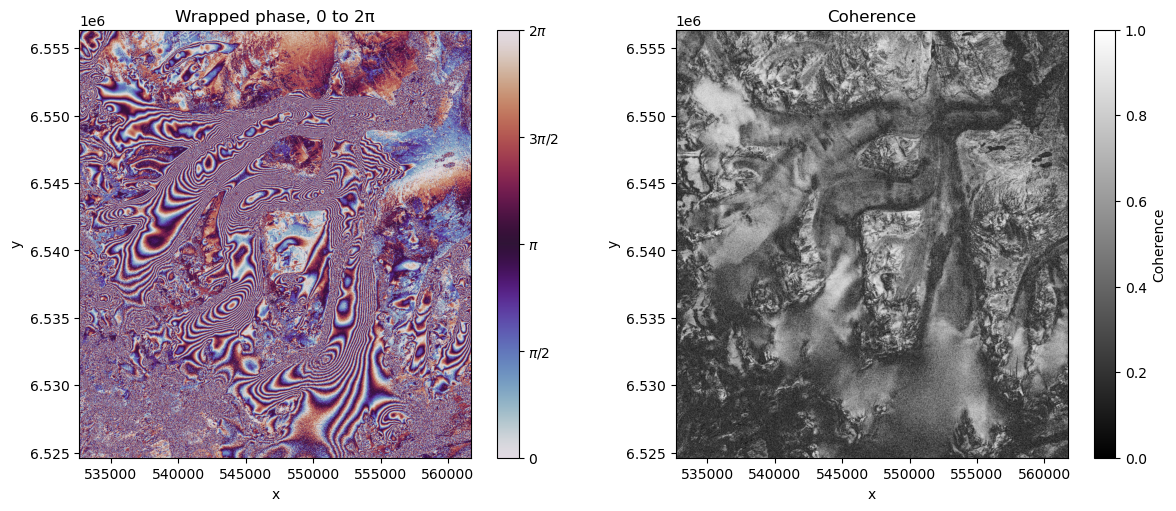

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Wrapped phase
im0 = axes[0].imshow(
    ds_crop["wrapped_phase_0_2pi"],
    extent=[
        float(ds_crop.x.min()),
        float(ds_crop.x.max()),
        float(ds_crop.y.min()),
        float(ds_crop.y.max()),
    ],
    origin="upper",
    cmap="twilight",
    vmin=0,
    vmax=2 * np.pi,
)

axes[0].set_title("Wrapped phase, 0 to 2π")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

cbar0 = fig.colorbar(im0, ax=axes[0])
cbar0.set_ticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
cbar0.set_ticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])

# Coherence
im1 = axes[1].imshow(
    ds_crop["coherence"],
    extent=[
        float(ds_crop.x.min()),
        float(ds_crop.x.max()),
        float(ds_crop.y.min()),
        float(ds_crop.y.max()),
    ],
    origin="upper",
    cmap="gray",
    vmin=0,
    vmax=1,
)

axes[1].set_title("Coherence")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

fig.colorbar(im1, ax=axes[1], label="Coherence")

plt.show()

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Manually supplied transect endpoints
# Coordinates should be in the same projected CRS as ds_crop
# ============================================================

x0, y0 = 542138,6543150
x1, y1 = 539546,6546757

# Approximate sample spacing in map units.
# If your NISAR GUNW grid is 20 m, use 20. If it is 10 m, use 10.
sample_spacing = 20

In [34]:
# ============================================================
# Sample transect
# ============================================================

def sample_transect(ds, x0, y0, x1, y1, sample_spacing=20):
    """
    Sample wrapped phase and coherence along a projected-coordinate transect.

    This version does not require ds['valid'] to already exist.
    """

    length = np.hypot(x1 - x0, y1 - y0)
    n_samples = int(np.floor(length / sample_spacing)) + 1

    distance = np.linspace(0, length, n_samples)
    xs = np.linspace(x0, x1, n_samples)
    ys = np.linspace(y0, y1, n_samples)

    sampled = ds.interp(
        x=xr.DataArray(xs, dims="point"),
        y=xr.DataArray(ys, dims="point"),
        method="nearest",
    )

    wrapped_0_2pi = sampled["wrapped_phase_0_2pi"].values
    wrapped_pm_pi = sampled["wrapped_phase_pm_pi"].values
    coh = sampled["coherence"].values

    # Compute validity here
    valid = (
        np.isfinite(wrapped_0_2pi)
        & np.isfinite(wrapped_pm_pi)
        & np.isfinite(coh)
        & (coh > 0)
    )

    transect = pd.DataFrame({
        "point": np.arange(n_samples),
        "distance_m": distance,
        "x": xs,
        "y": ys,
        "wrapped_phase_0_2pi_rad": wrapped_0_2pi,
        "wrapped_phase_0_2pi_pi_units": wrapped_0_2pi / np.pi,
        "wrapped_phase_pm_pi_rad": wrapped_pm_pi,
        "wrapped_phase_pm_pi_pi_units": wrapped_pm_pi / np.pi,
        "coherence": coh,
        "valid": valid,
    })

    return transect


transect = sample_transect(
    ds_crop,
    x0=x0, y0=y0,
    x1=x1, y1=y1,
    sample_spacing=sample_spacing,
)

transect.head()

,point,distance_m,x,y,wrapped_phase_0_2pi_rad,wrapped_phase_0_2pi_pi_units,wrapped_phase_pm_pi_rad,wrapped_phase_pm_pi_pi_units,coherence,valid
0,0,0.000000,542138.000000,6.543150e+06,5.536896,1.762449,-0.746290,-0.237551,0.345934,True
1,1,20.007766,542126.324324,6.543166e+06,4.944715,1.573951,-1.338471,-0.426048,0.331298,True
2,2,40.015532,542114.648649,6.543182e+06,0.180589,0.057483,0.180589,0.057483,0.352194,True
3,3,60.023299,542102.972973,6.543199e+06,0.180589,0.057483,0.180589,0.057483,0.352194,True
4,4,80.031065,542091.297297,6.543215e+06,5.262707,1.675171,-1.020479,-0.324828,0.279841,True


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_transect_overview_and_zoom(
    ds,
    x0, y0, x1, y1,
    zoom_buffer_m=1500,
    background="wrapped_phase",
    coh_min=None,
    figsize=(10, 5),
    cmap="twilight",
    save_path=None,
):
    """
    Plot two subplots:
      1) overview of the full cropped area with the transect
      2) zoomed-in view around the transect

    Parameters
    ----------
    ds : xr.Dataset
        Should contain:
        - wrapped_phase_0_2pi
        - coherence
    x0, y0, x1, y1 : float
        Transect endpoints in projected coordinates.
    zoom_buffer_m : float
        Buffer around the transect for the zoomed panel.
    background : str
        "wrapped_phase" or "coherence"
    coh_min : float or None
        If provided and background == "wrapped_phase", mask low-coherence pixels.
    figsize : tuple
        Figure size.
    cmap : str
        Colormap for wrapped phase.
    save_path : str or Path or None
        If provided, save figure.

    Returns
    -------
    fig, axes
    """

    # --------------------------------------------------------
    # Build zoomed subset
    # --------------------------------------------------------
    zoom_minx = min(x0, x1) - zoom_buffer_m
    zoom_maxx = max(x0, x1) + zoom_buffer_m
    zoom_miny = min(y0, y1) - zoom_buffer_m
    zoom_maxy = max(y0, y1) + zoom_buffer_m

    ds_zoom = ds.rio.clip_box(
        minx=zoom_minx,
        miny=zoom_miny,
        maxx=zoom_maxx,
        maxy=zoom_maxy,
    )

    # --------------------------------------------------------
    # Choose background
    # --------------------------------------------------------
    if background == "wrapped_phase":
        bg_full = ds["wrapped_phase_0_2pi"]
        bg_zoom = ds_zoom["wrapped_phase_0_2pi"]

        if coh_min is not None:
            bg_full = bg_full.where(ds["coherence"] >= coh_min)
            bg_zoom = bg_zoom.where(ds_zoom["coherence"] >= coh_min)

        vmin, vmax = 0, 2 * np.pi
        cbar_label = "Wrapped phase"
        cbar_ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
        cbar_ticklabels = ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
        plot_cmap = cmap

    elif background == "coherence":
        bg_full = ds["coherence"]
        bg_zoom = ds_zoom["coherence"]

        vmin, vmax = 0, 1
        cbar_label = "Coherence"
        cbar_ticks = None
        cbar_ticklabels = None
        plot_cmap = "gray"

    else:
        raise ValueError("background must be 'wrapped_phase' or 'coherence'")

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    # ------------------------
    # Overview panel
    # ------------------------
    ax0 = axes[0]
    im0 = bg_full.plot.imshow(
        ax=ax0,
        cmap=plot_cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
    )

    ax0.plot([x0, x1], [y0, y1], color="black", linewidth=2)
    ax0.scatter([x0, x1], [y0, y1], color="black", s=30, zorder=5)

    ax0.text(x0, y0, " A", fontsize=10, va="bottom", ha="left", color="black")
    ax0.text(x1, y1, " A'", fontsize=10, va="bottom", ha="left", color="black")

    # Draw zoom box
    rect = Rectangle(
        (zoom_minx, zoom_miny),
        zoom_maxx - zoom_minx,
        zoom_maxy - zoom_miny,
        fill=False,
        edgecolor="black",
        linewidth=1.5,
        linestyle="--",
    )
    ax0.add_patch(rect)

    ax0.set_title("Overview")
    ax0.set_xlabel("Easting (m)")
    ax0.set_ylabel("Northing (m)")
    ax0.set_aspect("equal")

    # ------------------------
    # Zoom panel
    # ------------------------
    ax1 = axes[1]
    im1 = bg_zoom.plot.imshow(
        ax=ax1,
        cmap=plot_cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
    )

    ax1.plot([x0, x1], [y0, y1], color="black", linewidth=2)
    ax1.scatter([x0, x1], [y0, y1], color="black", s=30, zorder=5)

    ax1.text(x0, y0, " A", fontsize=10, va="bottom", ha="left", color="black")
    ax1.text(x1, y1, " A'", fontsize=10, va="bottom", ha="left", color="black")

    ax1.set_title("Zoomed transect view")
    ax1.set_xlabel("Easting (m)")
    ax1.set_ylabel("Northing (m)")
    ax1.set_aspect("equal")

    # --------------------------------------------------------
    # Shared colorbar
    # --------------------------------------------------------
    cbar = fig.colorbar(im1, ax=axes, shrink=0.88)
    cbar.set_label(cbar_label)

    if cbar_ticks is not None:
        cbar.set_ticks(cbar_ticks)
        cbar.set_ticklabels(cbar_ticklabels)

    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

    return fig, axes

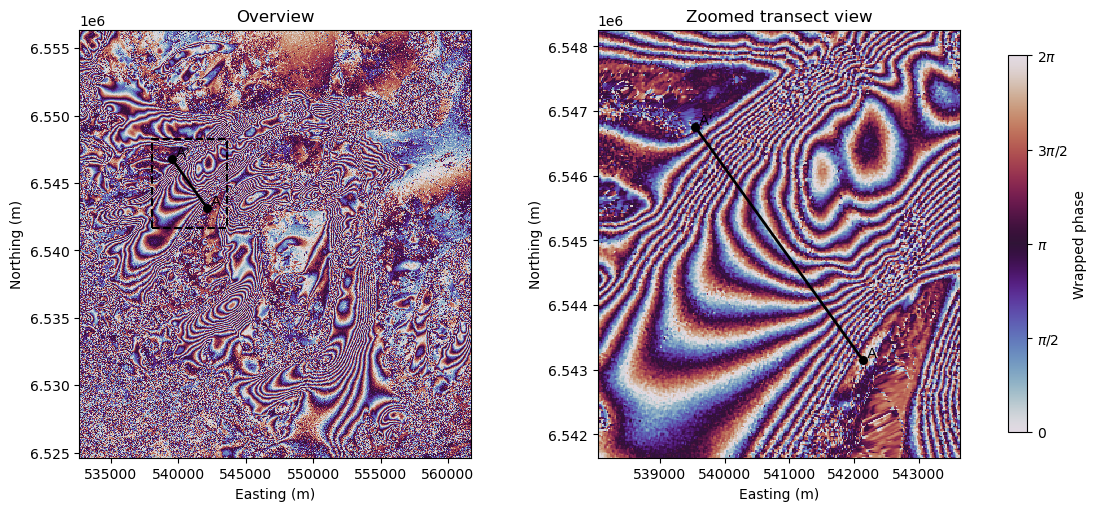

(<Figure size 1100x500 with 3 Axes>,
 array([<Axes: title={'center': 'Overview'}, xlabel='Easting (m)', ylabel='Northing (m)'>,
        <Axes: title={'center': 'Zoomed transect view'}, xlabel='Easting (m)', ylabel='Northing (m)'>],
       dtype=object))

In [40]:
plot_transect_overview_and_zoom(
    ds_crop,
    x0=x0, y0=y0,
    x1=x1, y1=y1,
    zoom_buffer_m=1500,
    background="wrapped_phase",
    coh_min=0.0,
    figsize=(11, 5),
    save_path="transect_overview_and_zoom.png",
)

Number of transect pixels: 223


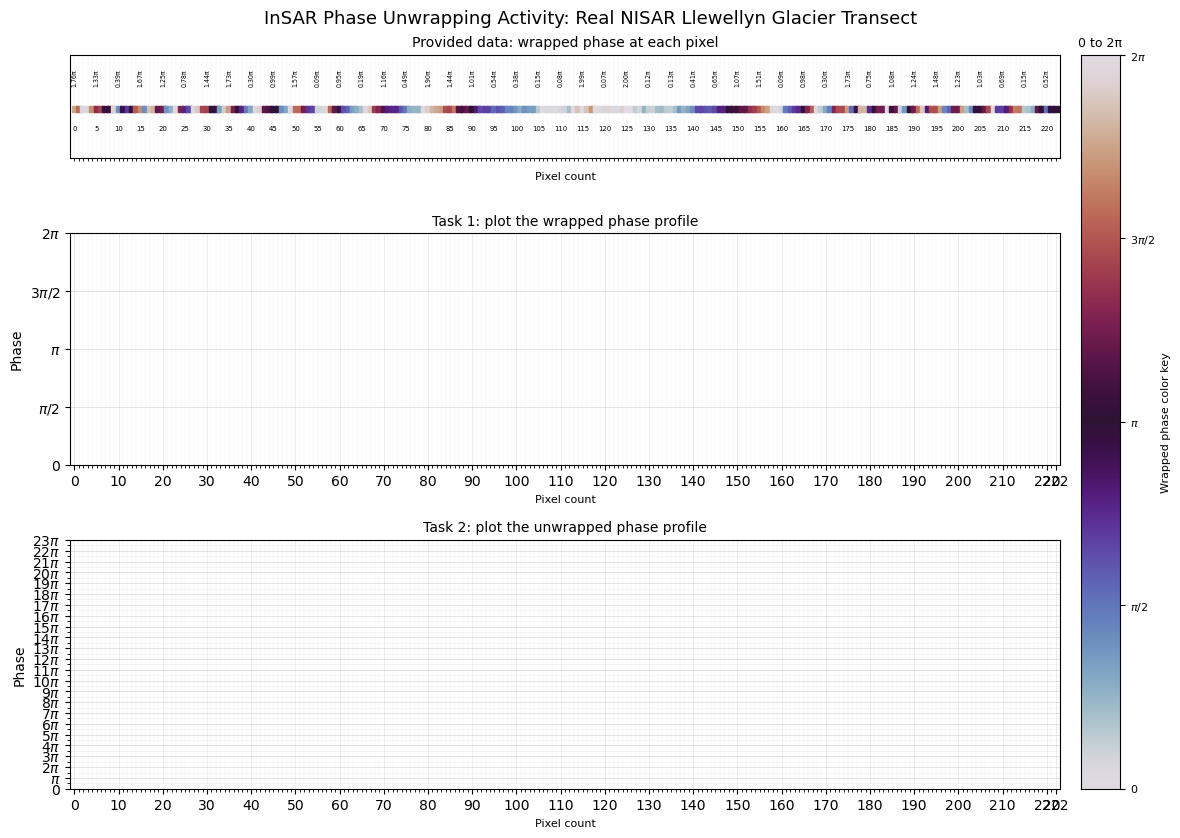

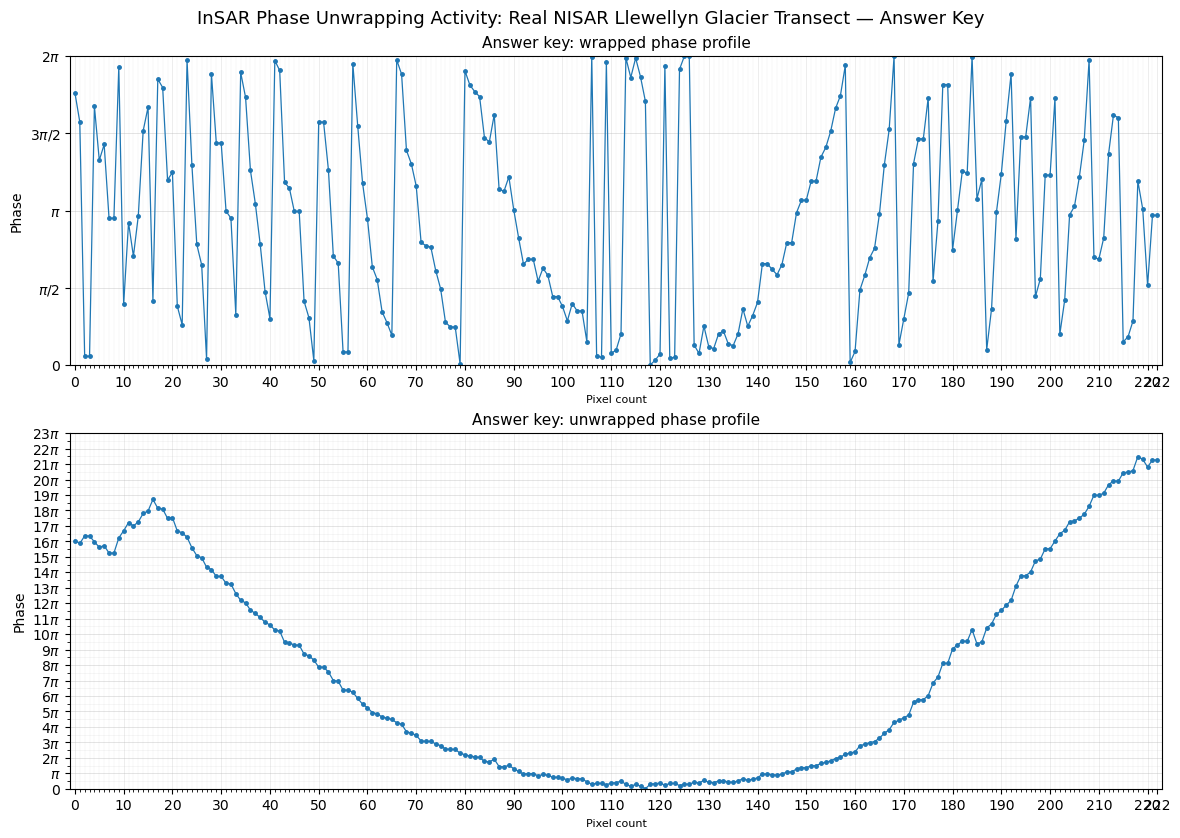

Saved worksheet PNG: nisar_transect_unwrapping_activity.png
Saved worksheet PDF: nisar_transect_unwrapping_activity.pdf
Saved answer PNG:    nisar_transect_unwrapping_answer_key.png
Saved answer PDF:    nisar_transect_unwrapping_answer_key.pdf
Saved values CSV:    nisar_transect_unwrapping_values_with_answers.csv


In [44]:
# ============================================================
# User settings
# ============================================================

# Output paths
out_dir = Path(".")
worksheet_png = out_dir / "nisar_transect_unwrapping_activity.png"
worksheet_pdf = out_dir / "nisar_transect_unwrapping_activity.pdf"
answer_png = out_dir / "nisar_transect_unwrapping_answer_key.png"
answer_pdf = out_dir / "nisar_transect_unwrapping_answer_key.pdf"
csv_out = out_dir / "nisar_transect_unwrapping_values_with_answers.csv"

# A4 landscape size in inches
figsize_a4_landscape = (11.69, 8.27)

# Label density for the long top strip
# 223 pixels is too many to label every one legibly on A4.
value_label_every = 5      # wrapped phase value above every nth pixel
pixel_label_every = 5     # pixel number below every nth pixel
major_xtick_every = 10     # major x ticks on student plots
minor_xtick_every = 1      # vertical guide line every pixel

# Optional: manually define glacier region indices if you want shading.
# Set to None to disable.
glacier_start_idx = None
glacier_end_idx = None

# Optional title
activity_title = "InSAR Phase Unwrapping Activity: Real NISAR Llewellyn Glacier Transect"


# ============================================================
# Pull data from transect
# ============================================================

xpix = np.asarray(transect["point"].values)
wrapped_0_2pi = np.asarray(transect["wrapped_phase_0_2pi_rad"].values)
wrapped_pm_pi = np.asarray(transect["wrapped_phase_pm_pi_rad"].values)

n_pixels = len(xpix)
print(f"Number of transect pixels: {n_pixels}")

# Build a simple 1D unwrapped answer from [-pi, pi] phase
unwrapped_answer = np.unwrap(wrapped_pm_pi)

# Shift so the minimum is at zero for easier plotting in the worksheet style
unwrapped_answer = unwrapped_answer - np.nanmin(unwrapped_answer)

# Add answers back into dataframe and save
transect_out = transect.copy()
transect_out["unwrapped_answer_rad"] = unwrapped_answer
transect_out["unwrapped_answer_pi_units"] = unwrapped_answer / np.pi
transect_out.to_csv(csv_out, index=False)

# Dynamic y-axis max for unwrapped plot
ymax_unwrapped_pi = int(np.ceil(np.nanmax(unwrapped_answer) / np.pi)) + 1
ymax_unwrapped_pi = max(ymax_unwrapped_pi, 4)


# ============================================================
# Helper functions
# ============================================================

def pi_ticklabels_0_2pi():
    ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    labels = ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
    return ticks, labels


def integer_pi_label(k):
    if k == 0:
        return "0"
    elif k == 1:
        return r"$\pi$"
    else:
        return rf"${k}\pi$"


def format_phase_value(val, mode="pi"):
    if mode == "pi":
        return f"{val/np.pi:.2f}π"
    elif mode == "rad":
        return f"{val:.2f}"
    else:
        raise ValueError("mode must be 'pi' or 'rad'")


def add_pixel_guides(ax, n_pixels, major_every=20, minor_every=1):
    major_ticks = np.arange(0, n_pixels, major_every)
    if len(major_ticks) == 0 or major_ticks[-1] != n_pixels - 1:
        major_ticks = np.append(major_ticks, n_pixels - 1)

    minor_ticks = np.arange(0, n_pixels, minor_every)

    ax.set_xticks(major_ticks)
    ax.set_xticks(minor_ticks, minor=True)

    ax.grid(True, axis="x", which="minor", linewidth=0.35, alpha=0.18)
    ax.grid(True, axis="x", which="major", linewidth=0.55, alpha=0.28)


def shade_optional_glacier_region(ax, glacier_start_idx=None, glacier_end_idx=None, n_pixels=None):
    if glacier_start_idx is None or glacier_end_idx is None:
        return

    ax.axvspan(-0.5, glacier_start_idx - 0.5, alpha=0.08)
    ax.axvspan(glacier_start_idx - 0.5, glacier_end_idx + 0.5, alpha=0.03)
    ax.axvspan(glacier_end_idx + 0.5, n_pixels - 0.5, alpha=0.08)


def set_wrapped_phase_axis(ax):
    ticks, labels = pi_ticklabels_0_2pi()
    ax.set_ylim(0, 2*np.pi)
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)
    ax.set_ylabel("Phase")
    ax.grid(True, axis="y", which="major", linewidth=0.7, alpha=0.35)


def set_unwrapped_phase_axis(ax, ymax_pi):
    major = np.arange(0, ymax_pi + 1, 1) * np.pi
    minor = np.arange(0, 2 * ymax_pi + 1, 1) * np.pi / 2

    ax.set_ylim(0, ymax_pi * np.pi)
    ax.set_yticks(major)
    ax.set_yticklabels([integer_pi_label(k) for k in range(ymax_pi + 1)])
    ax.set_yticks(minor, minor=True)

    ax.set_ylabel("Phase")
    ax.grid(True, axis="y", which="major", linewidth=0.7, alpha=0.35)
    ax.grid(True, axis="y", which="minor", linewidth=0.4, alpha=0.20)


def draw_phase_strip(
    ax,
    xpix,
    wrapped_phase,
    n_pixels,
    value_label_every=5,
    pixel_label_every=10,
    glacier_start_idx=None,
    glacier_end_idx=None,
):
    shade_optional_glacier_region(
        ax,
        glacier_start_idx=glacier_start_idx,
        glacier_end_idx=glacier_end_idx,
        n_pixels=n_pixels,
    )
    add_pixel_guides(ax, n_pixels, major_every=major_xtick_every, minor_every=minor_xtick_every)

    ax.scatter(
        xpix,
        np.zeros_like(xpix),
        c=wrapped_phase,
        cmap="twilight",
        vmin=0,
        vmax=2*np.pi,
        s=18,
        marker="s",
        zorder=3
    )

    # Wrapped phase numeric labels above strip
    for xi, val in zip(xpix, wrapped_phase):
        if xi % value_label_every == 0:
            ax.text(
                xi, 0.16,
                format_phase_value(val, mode="pi"),
                ha="center", va="bottom",
                rotation=90, fontsize=4.5
            )

    # Pixel numbers below strip
    for xi in xpix:
        if xi % pixel_label_every == 0:
            ax.text(
                xi, -0.11,
                str(int(xi)),
                ha="center", va="top",
                fontsize=5
            )

    if glacier_start_idx is not None and glacier_end_idx is not None:
        ax.text(glacier_start_idx / 2, -0.26, "stable", ha="center", va="center", fontsize=7)
        ax.text((glacier_start_idx + glacier_end_idx) / 2, -0.26, "glacier", ha="center", va="center", fontsize=7)
        ax.text((glacier_end_idx + n_pixels - 1) / 2, -0.26, "stable", ha="center", va="center", fontsize=7)

    ax.set_xlim(-1, n_pixels)
    ax.set_ylim(-0.34, 0.38)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlabel("Pixel count", fontsize=8)
    ax.set_title("Provided data: wrapped phase at each pixel", fontsize=10)


# ============================================================
# Worksheet figure
# ============================================================

fig = plt.figure(figsize=figsize_a4_landscape, constrained_layout=True)
gs = fig.add_gridspec(
    nrows=3, ncols=2,
    width_ratios=[20, 0.8],
    height_ratios=[0.6, 1.35, 1.45],
)

# ------------------------------------------------------------
# Top strip
# ------------------------------------------------------------
ax_strip = fig.add_subplot(gs[0, 0])
draw_phase_strip(
    ax_strip,
    xpix=xpix,
    wrapped_phase=wrapped_0_2pi,
    n_pixels=n_pixels,
    value_label_every=value_label_every,
    pixel_label_every=pixel_label_every,
    glacier_start_idx=glacier_start_idx,
    glacier_end_idx=glacier_end_idx,
)

# ------------------------------------------------------------
# Wrapped phase student plot
# ------------------------------------------------------------
ax_wrapped = fig.add_subplot(gs[1, 0])
shade_optional_glacier_region(
    ax_wrapped,
    glacier_start_idx=glacier_start_idx,
    glacier_end_idx=glacier_end_idx,
    n_pixels=n_pixels,
)
add_pixel_guides(ax_wrapped, n_pixels, major_every=major_xtick_every, minor_every=minor_xtick_every)
set_wrapped_phase_axis(ax_wrapped)
ax_wrapped.set_xlim(-1, n_pixels)
ax_wrapped.set_xlabel("Pixel count", fontsize=8)
ax_wrapped.set_title("Task 1: plot the wrapped phase profile", fontsize=10)

# ------------------------------------------------------------
# Unwrapped phase student plot
# ------------------------------------------------------------
ax_unwrapped = fig.add_subplot(gs[2, 0])
shade_optional_glacier_region(
    ax_unwrapped,
    glacier_start_idx=glacier_start_idx,
    glacier_end_idx=glacier_end_idx,
    n_pixels=n_pixels,
)
add_pixel_guides(ax_unwrapped, n_pixels, major_every=major_xtick_every, minor_every=minor_xtick_every)
set_unwrapped_phase_axis(ax_unwrapped, ymax_unwrapped_pi)
ax_unwrapped.set_xlim(-1, n_pixels)
ax_unwrapped.set_xlabel("Pixel count", fontsize=8)
ax_unwrapped.set_title("Task 2: plot the unwrapped phase profile", fontsize=10)

# ------------------------------------------------------------
# Wrapped-phase color key
# ------------------------------------------------------------
ax_cb = fig.add_subplot(gs[:, 1])
phase_strip = np.linspace(0, 2*np.pi, 512)[:, None]
ax_cb.imshow(
    phase_strip,
    aspect="auto",
    extent=[0, 1, 0, 2*np.pi],
    cmap="twilight",
    origin="lower",
)
ax_cb.set_xticks([])
ticks, labels = pi_ticklabels_0_2pi()
ax_cb.set_yticks(ticks)
ax_cb.set_yticklabels(labels, fontsize=8)
ax_cb.yaxis.tick_right()
ax_cb.yaxis.set_label_position("right")
ax_cb.set_ylabel("Wrapped phase color key", fontsize=8)
ax_cb.set_title("0 to 2π", fontsize=9)

fig.suptitle(activity_title, fontsize=13)

# fig.text(
#     0.5, 0.012,
#     "Note: To keep labels legible on A4 paper, only every "
#     f"{value_label_every}th wrapped-phase value and every {pixel_label_every}th pixel number are shown.",
#     ha="center", fontsize=7
# )

fig.savefig(worksheet_png, dpi=300, bbox_inches="tight")
fig.savefig(worksheet_pdf, dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# Answer key figure
# ============================================================

fig2 = plt.figure(figsize=figsize_a4_landscape, constrained_layout=True)
gs2 = fig2.add_gridspec(
    nrows=2, ncols=1,
    height_ratios=[1.0, 1.15],
)

# ------------------------------------------------------------
# Answer 1: wrapped phase
# ------------------------------------------------------------
axA = fig2.add_subplot(gs2[0, 0])
shade_optional_glacier_region(
    axA,
    glacier_start_idx=glacier_start_idx,
    glacier_end_idx=glacier_end_idx,
    n_pixels=n_pixels,
)
add_pixel_guides(axA, n_pixels, major_every=major_xtick_every, minor_every=minor_xtick_every)
set_wrapped_phase_axis(axA)
axA.plot(xpix, wrapped_0_2pi, marker="o", linewidth=0.9, markersize=2.5)
axA.set_xlim(-1, n_pixels)
axA.set_xlabel("Pixel count", fontsize=8)
axA.set_title("Answer key: wrapped phase profile", fontsize=11)

# ------------------------------------------------------------
# Answer 2: unwrapped phase
# ------------------------------------------------------------
axB = fig2.add_subplot(gs2[1, 0])
shade_optional_glacier_region(
    axB,
    glacier_start_idx=glacier_start_idx,
    glacier_end_idx=glacier_end_idx,
    n_pixels=n_pixels,
)
add_pixel_guides(axB, n_pixels, major_every=major_xtick_every, minor_every=minor_xtick_every)
set_unwrapped_phase_axis(axB, ymax_unwrapped_pi)
axB.plot(xpix, unwrapped_answer, marker="o", linewidth=0.9, markersize=2.5)
axB.set_xlim(-1, n_pixels)
axB.set_xlabel("Pixel count", fontsize=8)
axB.set_title("Answer key: unwrapped phase profile", fontsize=11)

fig2.suptitle(f"{activity_title} — Answer Key", fontsize=13)

fig2.savefig(answer_png, dpi=300, bbox_inches="tight")
fig2.savefig(answer_pdf, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved worksheet PNG: {worksheet_png}")
print(f"Saved worksheet PDF: {worksheet_pdf}")
print(f"Saved answer PNG:    {answer_png}")
print(f"Saved answer PDF:    {answer_pdf}")
print(f"Saved values CSV:    {csv_out}")